In [4]:
import  pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [5]:
#read data from excel sheet 
df=pd.read_csv('C:/Users/DEEPADHARSHINI/OneDrive/Desktop/FAOSTAT_data.csv')
df.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2019,2019,ha,29203.0,A,Official figure,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2019,2019,kg/ha,1308.3,A,Official figure,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,1371,"Almonds, in shell",2019,2019,t,38205.0,A,Official figure,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2020,2020,ha,22134.0,A,Official figure,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2020,2020,kg/ha,1775.9,A,Official figure,NaN


In [6]:
#remove unwanted columns
df.drop('Year Code', axis=1,inplace=True)

In [7]:
df.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2019,ha,29203.0,A,Official figure,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2019,kg/ha,1308.3,A,Official figure,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,1371,"Almonds, in shell",2019,t,38205.0,A,Official figure,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2020,ha,22134.0,A,Official figure,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2020,kg/ha,1775.9,A,Official figure,NaN


In [8]:
#checking the info of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224647 entries, 0 to 224646
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Domain Code       224647 non-null  object 
 1   Domain            224647 non-null  object 
 2   Area Code (M49)   224647 non-null  int64  
 3   Area              224647 non-null  object 
 4   Element Code      224647 non-null  int64  
 5   Element           224647 non-null  object 
 6   Item Code (CPC)   224642 non-null  object 
 7   Item              224647 non-null  object 
 8   Year              224647 non-null  int64  
 9   Unit              224645 non-null  object 
 10  Value             218130 non-null  float64
 11  Flag              224643 non-null  object 
 12  Flag Description  224634 non-null  object 
 13  Note              5098 non-null    object 
dtypes: float64(1), int64(3), object(10)
memory usage: 24.0+ MB


In [9]:
#checking the missing values in the dataset
missing_data=df.isnull().sum()

percentage=(missing_data/len(df))*100
print(missing_data)
print(percentage)


Domain Code              0
Domain                   0
Area Code (M49)          0
Area                     0
Element Code             0
Element                  0
Item Code (CPC)          5
Item                     0
Year                     0
Unit                     2
Value                 6517
Flag                     4
Flag Description        13
Note                219549
dtype: int64
Domain Code          0.000000
Domain               0.000000
Area Code (M49)      0.000000
Area                 0.000000
Element Code         0.000000
Element              0.000000
Item Code (CPC)      0.002226
Item                 0.000000
Year                 0.000000
Unit                 0.000890
Value                2.900996
Flag                 0.001781
Flag Description     0.005787
Note                97.730662
dtype: float64


In [10]:
#removing the columns with high null values
df.drop('Note',axis=1,inplace=True)

In [11]:
#checking the duplicates in the dataset

df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()




np.int64(0)

In [12]:
#checking no of rows and columns of the dataset
df.shape


(224647, 13)

In [13]:

df.describe()

,Area Code (M49),Element Code,Year,Value
count,224647.000000,224647.000000,224647.000000,2.181300e+05
mean,426.797932,5407.125285,2020.971658,8.984848e+05
std,254.501789,101.321826,1.403592,1.201902e+07
min,4.000000,5111.000000,2019.000000,0.000000e+00
25%,203.000000,5312.000000,2020.000000,9.370000e+02
50%,414.000000,5412.000000,2021.000000,7.228200e+03
75%,643.000000,5510.000000,2022.000000,5.135000e+04
max,894.000000,5513.000000,2023.000000,7.825858e+08


In [14]:
#filling the null values with mean and mode values

for column in df.columns:
    if df[column].dtype in ['int64','float64']:
        df[column].fillna(df[column].mean(), inplace=True)
    else:
        df[column].fillna(df[column].mode()[0], inplace=True)

print(df.isnull().sum())


C:\Users\DEEPADHARSHINI\AppData\Local\Temp\ipykernel_18928\3532958776.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mode()[0], inplace=True)
C:\Users\DEEPADHARSHINI\AppData\Local\Temp\ipykernel_18928\3532958776.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

Domain Code         0
Domain              0
Area Code (M49)     0
Area                0
Element Code        0
Element             0
Item Code (CPC)     0
Item                0
Year                0
Unit                0
Value               0
Flag                0
Flag Description    0
dtype: int64


In [15]:
#seperating the needed columns from the dataset
pro_col=['Area','Item','Element','Value','Year']
filtered_data=df[pro_col]
print(filtered_data)


               Area                    Item         Element          Value  \
0       Afghanistan       Almonds, in shell  Area harvested   29203.000000   
1       Afghanistan       Almonds, in shell           Yield    1308.300000   
2       Afghanistan       Almonds, in shell      Production   38205.000000   
3       Afghanistan       Almonds, in shell  Area harvested   22134.000000   
4       Afghanistan       Almonds, in shell           Yield    1775.900000   
...             ...                     ...             ...            ...   
224642     Zimbabwe  Whole milk, evaporated      Production    5010.210000   
224643     Zimbabwe  Whole milk, evaporated      Production    4795.700000   
224644     Zimbabwe  Whole milk, evaporated      Production    4921.050000   
224645     Zimbabwe  Whole milk, evaporated      Production    4966.370000   
224646     Zimbabwe                    Wine      Production  898484.835892   

        Year  
0       2019  
1       2019  
2       2019  
3  

In [16]:
print(filtered_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224647 entries, 0 to 224646
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Area     224647 non-null  object 
 1   Item     224647 non-null  object 
 2   Element  224647 non-null  object 
 3   Value    224647 non-null  float64
 4   Year     224647 non-null  int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB
None


In [17]:
data=df[pro_col]
data

,Area,Item,Element,Value,Year
0,Afghanistan,"Almonds, in shell",Area harvested,29203.000000,2019
1,Afghanistan,"Almonds, in shell",Yield,1308.300000,2019
2,Afghanistan,"Almonds, in shell",Production,38205.000000,2019
3,Afghanistan,"Almonds, in shell",Area harvested,22134.000000,2020
4,Afghanistan,"Almonds, in shell",Yield,1775.900000,2020
...,...,...,...,...,...
224642,Zimbabwe,"Whole milk, evaporated",Production,5010.210000,2019
224643,Zimbabwe,"Whole milk, evaporated",Production,4795.700000,2020
224644,Zimbabwe,"Whole milk, evaporated",Production,4921.050000,2021
224645,Zimbabwe,"Whole milk, evaporated",Production,4966.370000,2022


In [18]:
#pivot table
pivot_data=data.pivot_table(index=['Area','Item','Year'],
columns='Element',
values='Value').reset_index()



In [19]:


pivot_data

Element,Area,Item,Year,Area harvested,Laying,Milk Animals,Producing Animals/Slaughtered,Production,Stocks,Yield,Yield/Carcass Weight
0,Afghanistan,"Almonds, in shell",2019,29203.0,NaN,NaN,NaN,38205.000000,NaN,1308.3,NaN
1,Afghanistan,"Almonds, in shell",2020,22134.0,NaN,NaN,NaN,39307.000000,NaN,1775.9,NaN
2,Afghanistan,"Almonds, in shell",2021,36862.0,NaN,NaN,NaN,64256.000000,NaN,1743.2,NaN
3,Afghanistan,"Almonds, in shell",2022,36462.0,NaN,NaN,NaN,63515.000000,NaN,1742.0,NaN
4,Afghanistan,"Almonds, in shell",2023,37000.0,NaN,NaN,NaN,67000.000000,NaN,1810.8,NaN
...,...,...,...,...,...,...,...,...,...,...,...
95920,Zimbabwe,"Whole milk, evaporated",2019,NaN,NaN,NaN,NaN,5010.210000,NaN,NaN,NaN
95921,Zimbabwe,"Whole milk, evaporated",2020,NaN,NaN,NaN,NaN,4795.700000,NaN,NaN,NaN
95922,Zimbabwe,"Whole milk, evaporated",2021,NaN,NaN,NaN,NaN,4921.050000,NaN,NaN,NaN
95923,Zimbabwe,"Whole milk, evaporated",2022,NaN,NaN,NaN,NaN,4966.370000,NaN,NaN,NaN


In [20]:
#checking outliers
for column in pivot_data.columns:
    if pivot_data[column].dtype in ('int64', 'float64'):
        Q1=pivot_data[column].quantile(0.25)
        Q3=pivot_data[column].quantile(0.75)

        IQR=Q3-Q1

        lower_bound=Q1-1.5*IQR
        upper_bound=Q3+1.5*IQR

        outliers=pivot_data[(pivot_data[column]<lower_bound) | (pivot_data[column]>upper_bound)]
        print(outliers[[column]])
    else:
        print('error')
        

    

error
error
Empty DataFrame
Columns: [Year]
Index: []
Element  Area harvested
25              84070.0
26              86099.0
132             89593.0
133             92584.0
134             92645.0
...                 ...
95892           97138.0
95893          104759.0
95894           99029.0
95895          154023.0
95896          136126.0

[8811 rows x 1 columns]
Element   Laying
2539     44500.0
2540     44800.0
2541     47500.0
2542     51500.0
2543     51620.0
...          ...
94077    77070.0
94078    81688.0
94079    85874.0
94080    88710.0
94081    85424.0

[162 rows x 1 columns]
Element  Milk Animals
322         3478070.0
323         3523277.0
324         3567559.0
325         3648399.0
326         3709761.0
...               ...
92914       5205000.0
92915       5354000.0
92916       5523000.0
92917       5688000.0
93735       3301384.0

[298 rows x 1 columns]
Element  Producing Animals/Slaughtered
92                           3567060.0
93                           3616042.0


In [21]:
pivot_data.to_csv('C:/Users/DEEPADHARSHINI/OneDrive/Desktop/Cleaned_Crop_data.csv',index=False)
print('its completed')

PermissionError: [Errno 13] Permission denied: 'C:/Users/DEEPADHARSHINI/OneDrive/Desktop/Cleaned_Crop_data.csv'

C:\Users\DEEPADHARSHINI\AppData\Local\Temp\ipykernel_18928\3748568277.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crop_counts.head(10).values, y=crop_counts.head(10).index, palette='viridis')


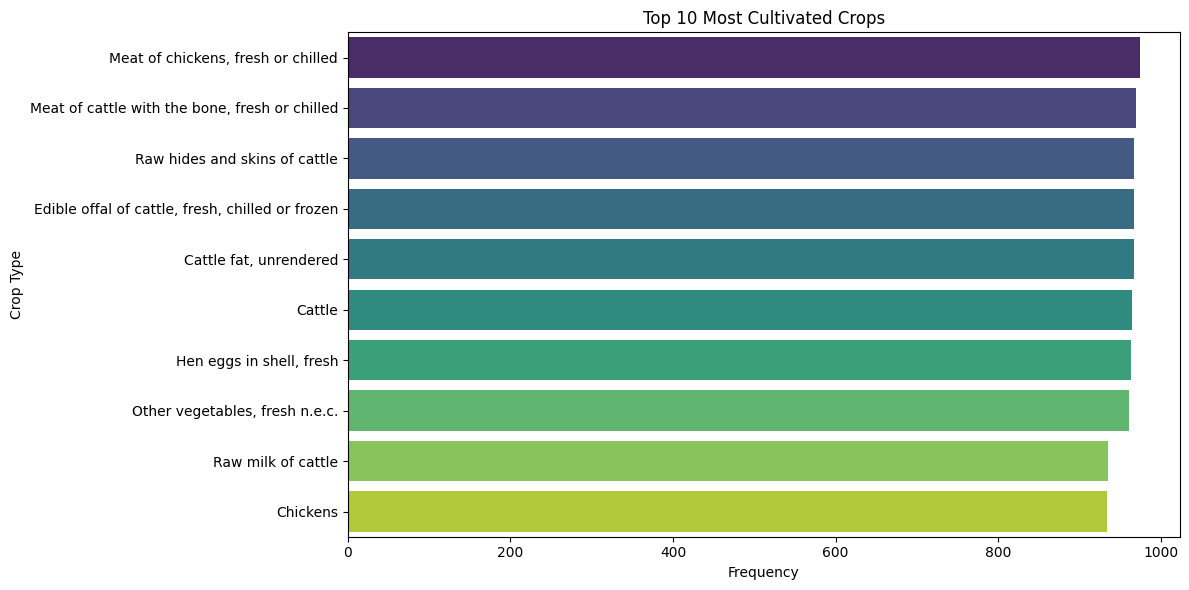

In [22]:
crop_counts = pivot_data['Item'].value_counts().sort_values(ascending=False)



# Plot the top 10 most cultivated crops
plt.figure(figsize=(12, 6))
sns.barplot(x=crop_counts.head(10).values, y=crop_counts.head(10).index, palette='viridis')
plt.title("Top 10 Most Cultivated Crops")
plt.xlabel("Frequency")
plt.ylabel("Crop Type")
plt.tight_layout()
plt.show()

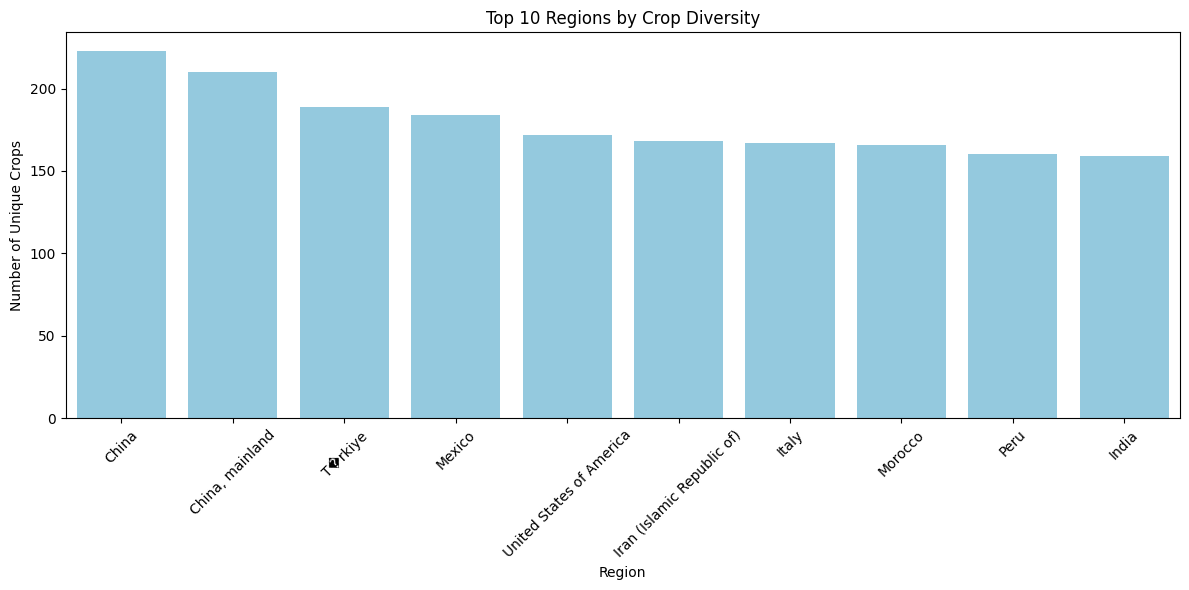

In [23]:
region_crop = pivot_data.groupby('Area')['Item'].nunique().sort_values(ascending=False)

region_data=pd.DataFrame(region_crop)

plt.figure(figsize=(12,6))
sns.barplot(x='Area',y='Item',data=region_data.head(10),color='skyblue')
plt.title("Top 10 Regions by Crop Diversity")
plt.xlabel("Region")
plt.ylabel("Number of Unique Crops")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

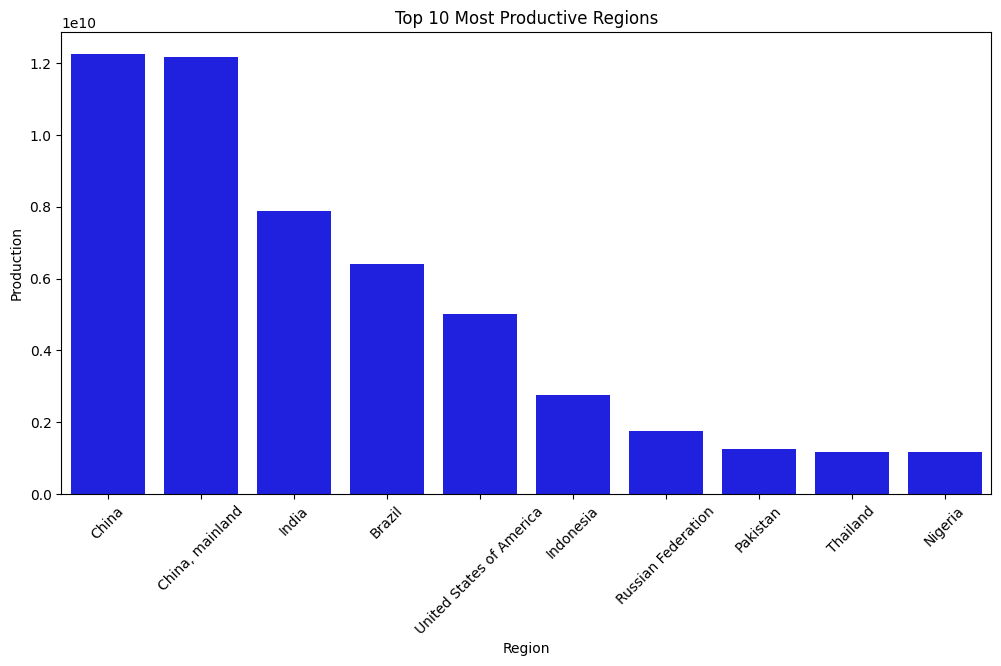

In [24]:
area_data=pivot_data.groupby('Area')['Production'].sum().sort_values(ascending=False)
area_df=pd.DataFrame(area_data)

plt.figure(figsize=(12,6))
sns.barplot(x='Area',y='Production',data=area_df.head(10),color='blue')
plt.title('Top 10 Most Productive Regions')
plt.xlabel('Region')
plt.ylabel('Production')
plt.xticks(rotation=45)
plt.show()


Year
2019    1.558549e+10
2020    1.565259e+10
2021    1.586344e+10
2022    1.599362e+10
2023    1.514476e+10
Name: Production, dtype: float64


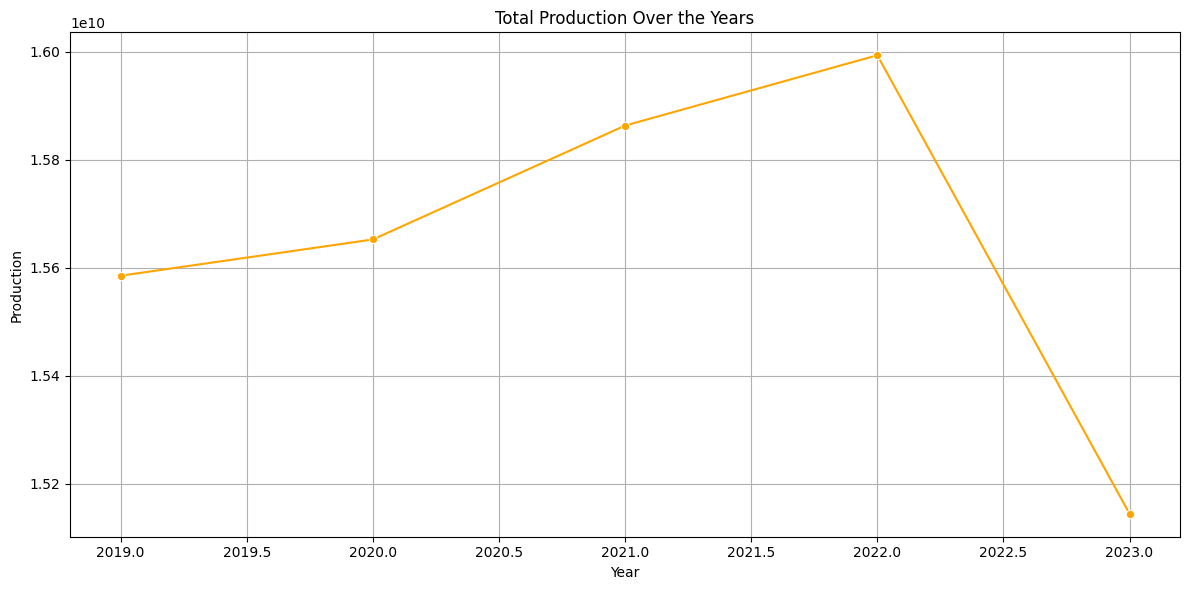

In [25]:
# Total production per year
yearly_production = pivot_data.groupby('Year')['Production'].sum()


print(yearly_production)

plt.figure(figsize=(12,6))
sns.lineplot(x=pivot_data['Year'],y=pivot_data.groupby('Year')['Production'].sum(),marker='o', color='orange')
plt.title("Total Production Over the Years")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid(True)
plt.tight_layout()
plt.show()



C:\Users\DEEPADHARSHINI\AppData\Local\Temp\ipykernel_18928\4247437472.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


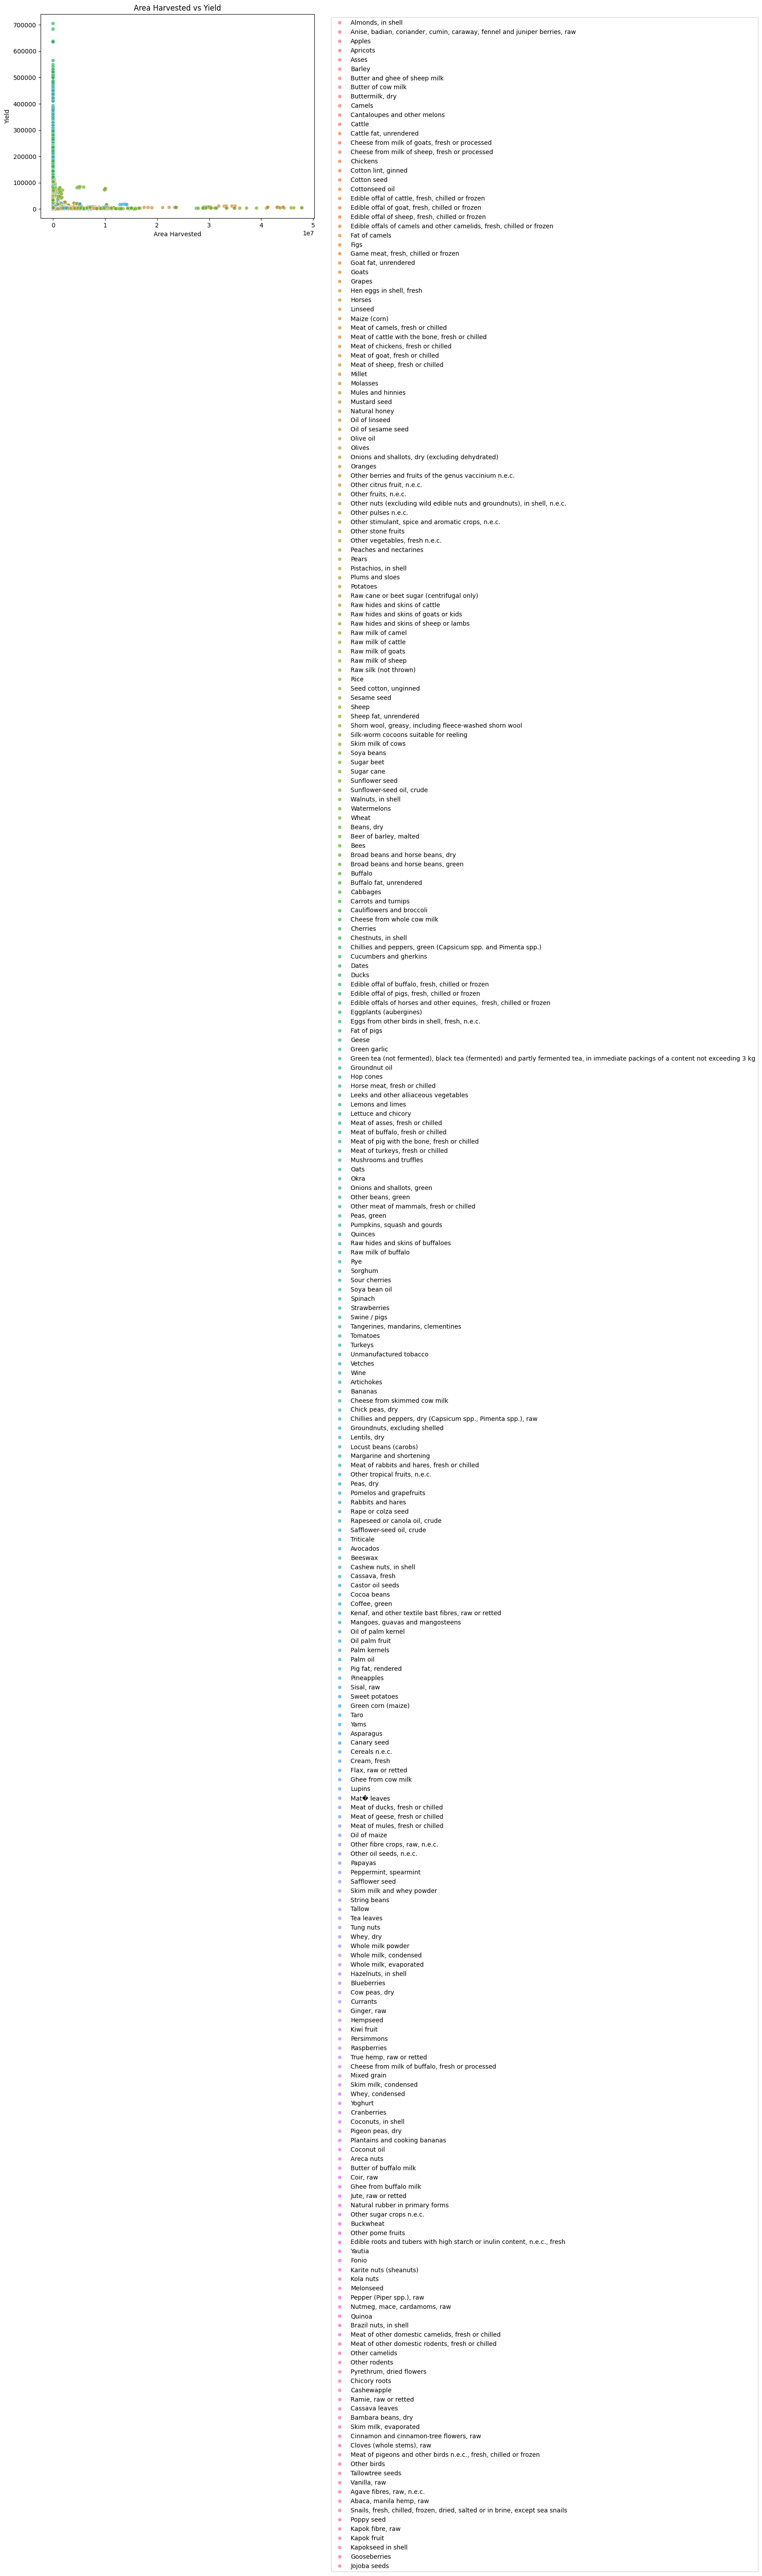

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pivot_data, x='Area harvested', y='Yield', hue='Item', legend=True, alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Area Harvested vs Yield")
plt.xlabel("Area Harvested")
plt.ylabel("Yield")
plt.tight_layout()
plt.show()

Element,Area harvested,Yield,Production
Element,,,
Area harvested,1.000000,-0.026551,0.636603
Yield,-0.026551,1.000000,0.068794
Production,0.636603,0.068794,1.000000


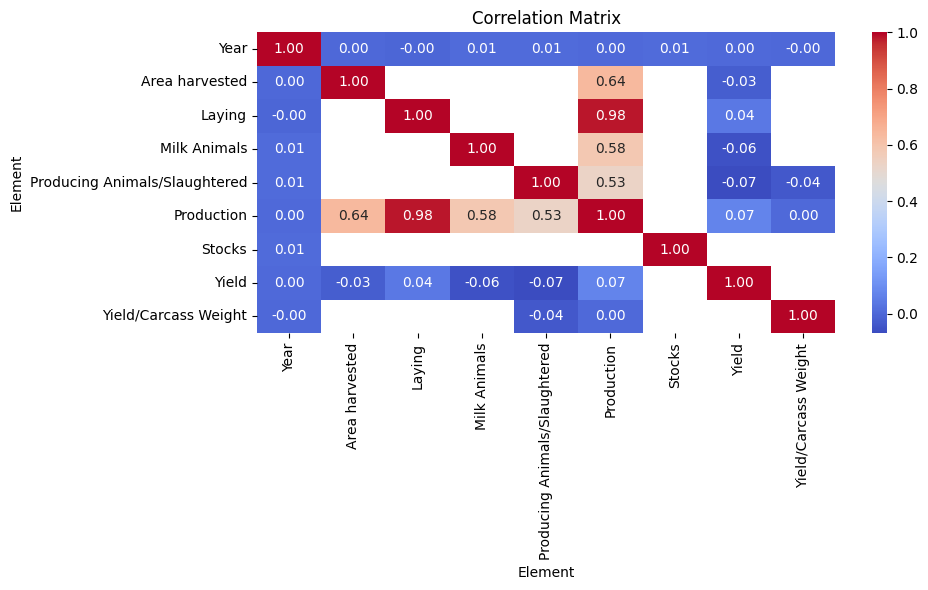

In [27]:
correlations = pivot_data[['Area harvested', 'Yield', 'Production']].corr()

style_tb=correlations.style.background_gradient(subset=['Area harvested', 'Yield', 'Production'],cmap='coolwarm')
display(style_tb)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


Item
Sugar cane                  1.024477e+10
Maize (corn)                7.267609e+09
Hen eggs in shell, fresh    5.913314e+09
Rice                        4.994867e+09
Wheat                       4.596531e+09
                                ...     
Ducks                       0.000000e+00
Buffalo                     0.000000e+00
Cattle                      0.000000e+00
Camels                      0.000000e+00
Swine / pigs                0.000000e+00
Name: Production, Length: 276, dtype: float64


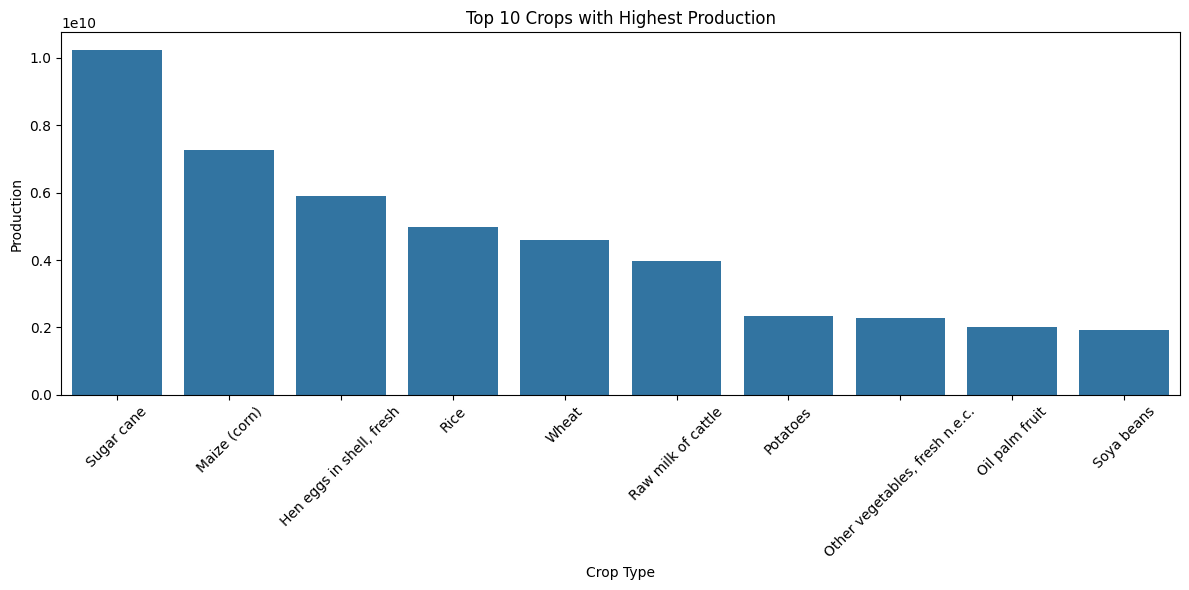

In [28]:
item_counts = pivot_data.groupby('Item')['Production'].sum().sort_values(ascending=False)
print(item_counts)
item_count=pd.DataFrame(item_counts)



# Plot the top 10 most cultivated crops
plt.figure(figsize=(12, 6))
sns.barplot(x='Item', y='Production',data=item_count.head(10))
plt.title("Top 10 Crops with Highest Production")
plt.xlabel("Crop Type")
plt.ylabel("Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sugar cane


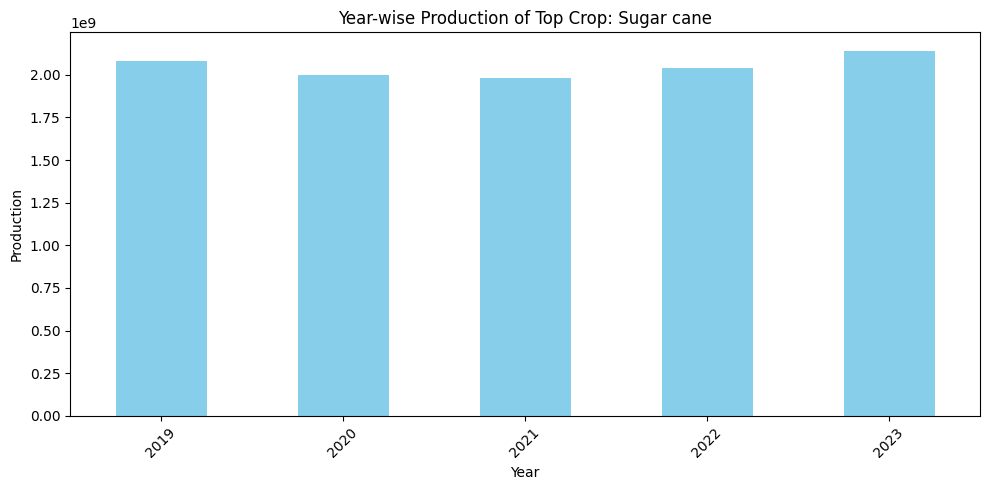

In [30]:
# Step 1: Find the top 1 crop
top_crop = pivot_data.groupby('Item')['Production'].sum().idxmax()
print(top_crop)

# Step 2: Filter data for only the top crop
top_crop_data = pivot_data[pivot_data['Item'] == top_crop]

# Step 3: Group by year and sum production
top_crop_yearly = top_crop_data.groupby('Year')['Production'].sum()

# Step 4: Plot it
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
top_crop_yearly.plot(kind='bar', color='skyblue')
plt.title(f"Year-wise Production of Top Crop: {top_crop}")
plt.xlabel("Year")
plt.ylabel("Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


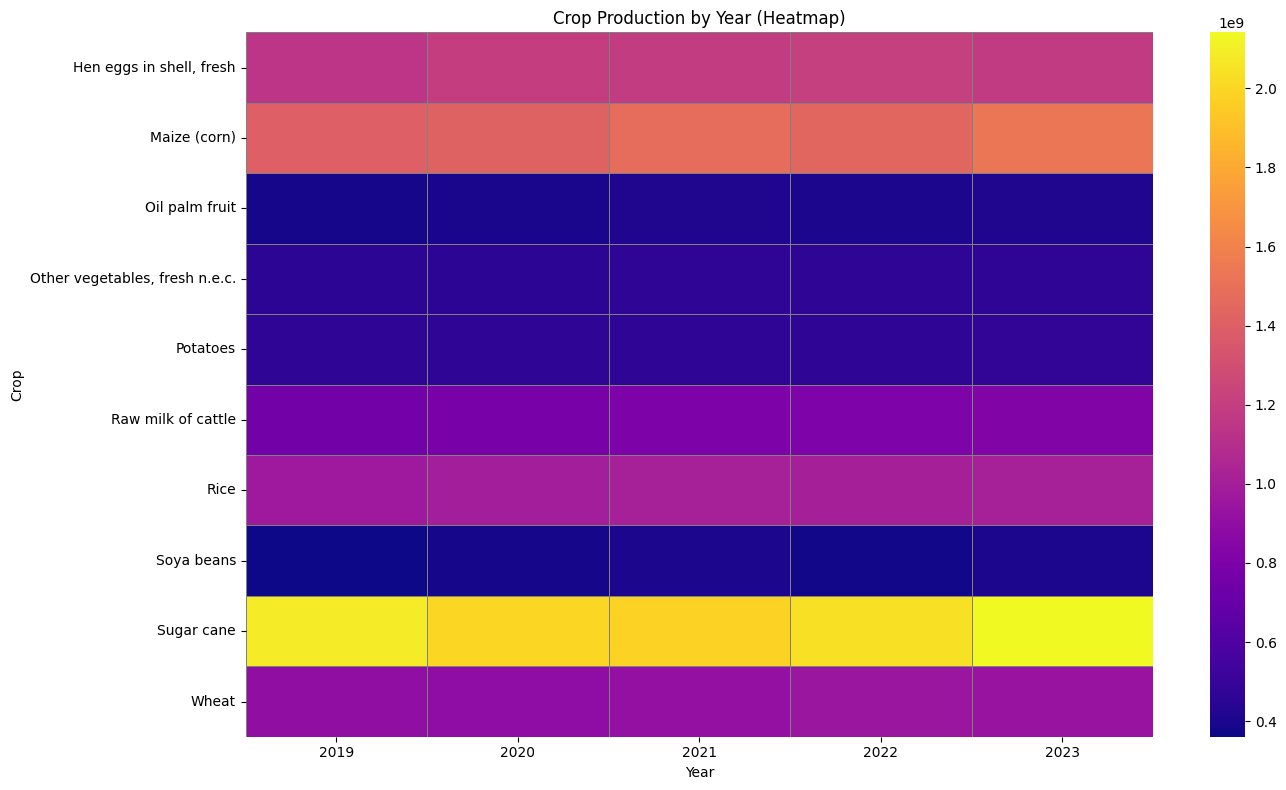

In [31]:
# Limit to top 10 crops by total production
top_crops = pivot_data.groupby('Item')['Production'].sum().nlargest(10).index
filtered_data = pivot_data[pivot_data['Item'].isin(top_crops)]

heatmap_data = filtered_data.pivot_table(index='Item', columns='Year', values='Production', aggfunc='sum')

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap='plasma', linewidths=0.5, linecolor='gray')

plt.title("Crop Production by Year (Heatmap)")
plt.xlabel("Year")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()